In [1]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 

import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint
import generate_data
from datasets import LetterStringDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# load checkpoints
copy_unstruct = CheckPoint.from_pt("../models/batching_strategies/MLC_batchunstruct_dallstudy1copy_nep20.pt")
unstruct = CheckPoint.from_pt("../models/batching_strategies/MLC_batchunstruct_dallstudy1_nep20.pt")

In [3]:
# load models and dataset
model_copy = copy_unstruct.load_model()
model_unstruct = unstruct.load_model()
val = unstruct.load_dataloaders(data_dir=f"../{unstruct.train_config.dir_data}", val_batch_size=5000, use_datasets=["val"])[0]

Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.7212
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 114,560
	best val loss achieved: 1.0794
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loaded following dataloaders:
val dataloader (n=22,912)


In [4]:
batch = next(iter(val))

In [12]:
" ".join(batch["xq_context"][4264])

'a b c d e f g h i j k l m n o p q r s t u v w x y z SOS c d e f IO c d e g SOS j k l m n o p'

In [11]:
for i, n_perm in enumerate(batch["n_perm"]):
    if n_perm == 0:
        print(f"index {i}: {batch["transformation"][i]}")

index 4: rr_sort
index 5: shift
index 12: extend_sequence
index 24: sort_group
index 42: rr_interleave
index 70: rr_sort
index 94: pred
index 126: replicate
index 137: reverse
index 142: sort_group
index 152: pred
index 166: extend_group
index 178: rr_sort
index 196: succ
index 208: fix_interleave
index 212: fix_extend
index 238: succ
index 251: sort_group
index 262: sort_group
index 277: fix_interleave
index 282: sort
index 285: replicate
index 290: fix_interleave
index 308: reverse
index 357: replicate
index 364: rr_interleave
index 369: reverse
index 374: succ
index 438: pred
index 491: rr_succ
index 494: rr_sort
index 520: fix_pred_succ
index 528: sort_group
index 530: extend_extend_succ
index 543: reverse
index 555: pred
index 556: fix_interleave
index 614: rr_sort
index 616: sort
index 621: rr_sort
index 638: fix_pred_succ
index 659: rr_interleave
index 693: succ
index 745: pred
index 746: extend_pred
index 748: extend_extend_succ
index 758: succ
index 790: rr_succ
index 797: sor

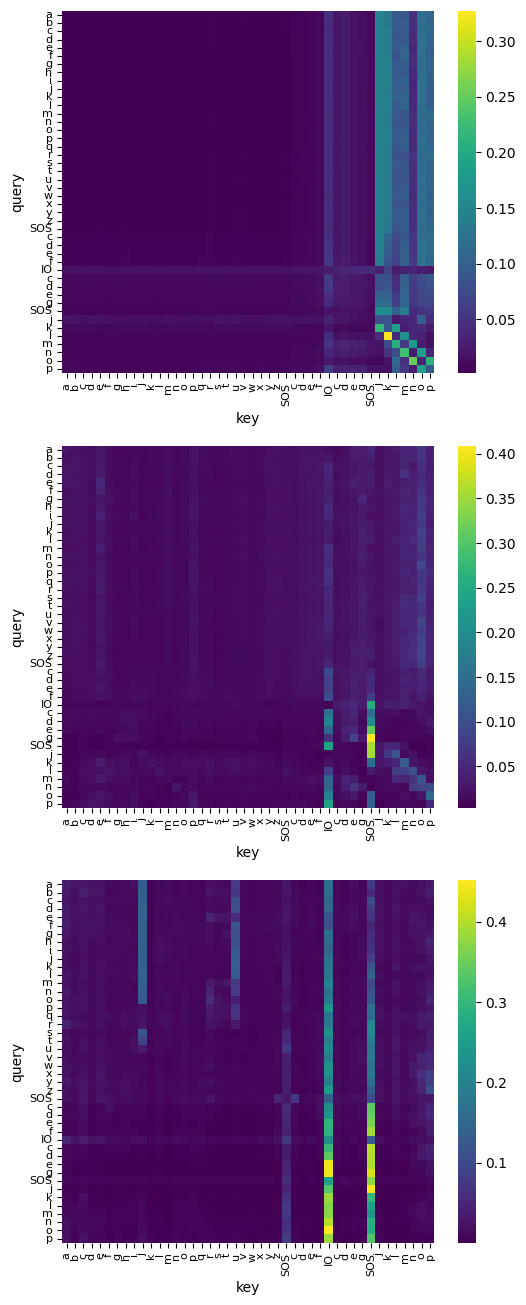

In [27]:
fig_noncopy, ax_noncopy = analysis_utils.get_encoder_attention_plot(model_unstruct, batch, idx=4264, titles=False)

In [29]:
fig_noncopy.savefig("../presentations/images/noncopy_encoder_attention.svg", format="svg")

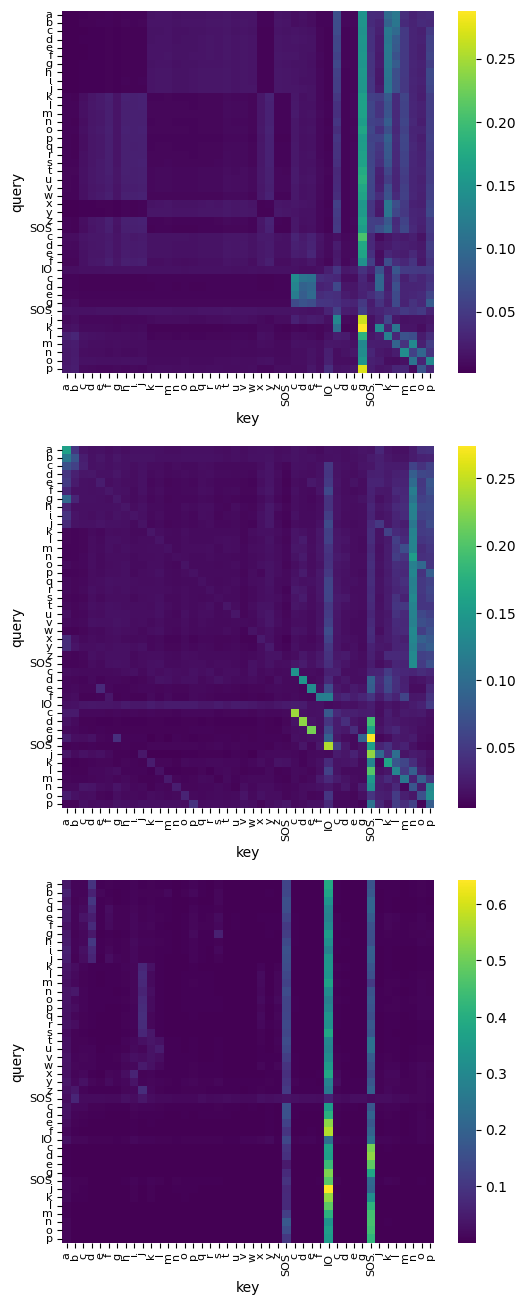

In [25]:
fig_copy, ax_copy = analysis_utils.get_encoder_attention_plot(model_copy, batch, idx=4264, titles=False)

In [30]:
fig_copy.savefig("../presentations/images/copy_encoder_attention.svg", format="svg")